<a href="https://colab.research.google.com/github/JoDa382/Opposition_Scouting_WWC_U20/blob/main/mapa_presion_joda_png.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 4.1 MB/s eta 0:00:00


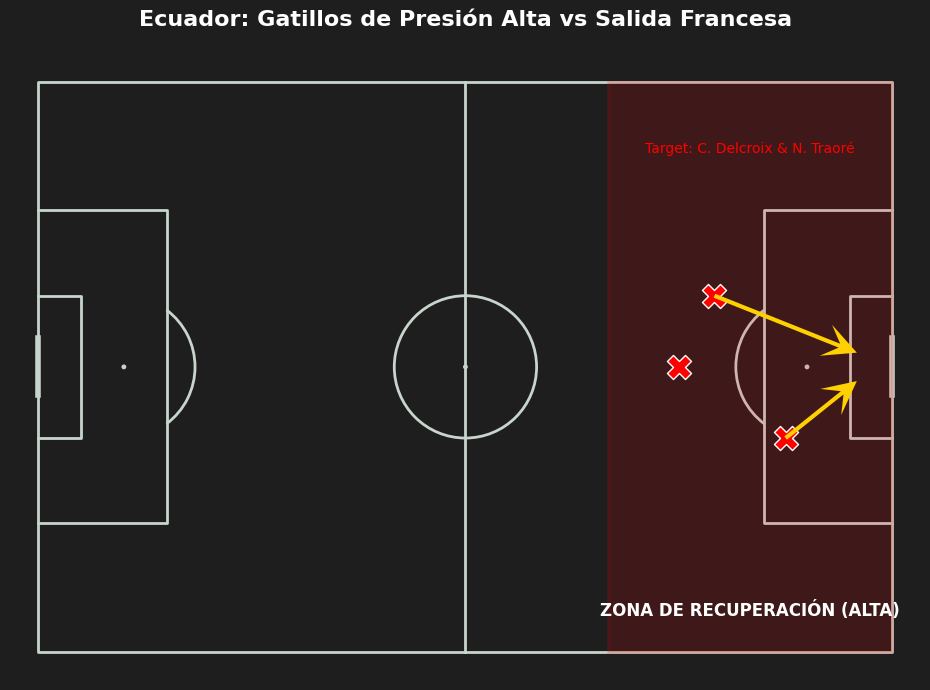

In [4]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import matplotlib.patches as patches

# 1. Configurar la Cancha (Estilo JodaAnalisis)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))
fig.patch.set_facecolor('#1e1e1e')

# 2. Resaltar la Zona de Presión (Último tercio de Francia / Salida de balón)
# Dibujamos un rectángulo rojo translúcido donde Ecuador debe morder la salida
zona_presion = patches.Rectangle((80, 0), 40, 80, linewidth=2, edgecolor='red', facecolor='red', alpha=0.15, zorder=1)
ax.add_patch(zona_presion)

# 3. Marcar los "Gatillos de Presión" (Errores detectados en video vs Corea)
# C. Delcroix (Central) y mediocentros
gatillos_x = [95, 105, 90]
gatillos_y = [30, 50, 40]
pitch.scatter(gatillos_x, gatillos_y, s=300, c='#ff0000', edgecolors='white', marker='X', ax=ax, zorder=2)

# 4. Flechas de Transición Ofensiva de Ecuador (Hacia la portería francesa en X=120)
pitch.arrows(95, 30, 115, 38, width=3, headwidth=8, headlength=8, color='#FFD100', ax=ax, zorder=3)
pitch.arrows(105, 50, 115, 42, width=3, headwidth=8, headlength=8, color='#FFD100', ax=ax, zorder=3)

# 5. Textos y Leyendas
plt.text(100, 75, 'ZONA DE RECUPERACIÓN (ALTA)', color='white', size=12, ha='center', fontweight='bold')
plt.text(100, 10, 'Target: C. Delcroix & N. Traoré', color='#ff0000', size=10, ha='center')

# Título del Gráfico
plt.title("Ecuador: Gatillos de Presión Alta vs Salida Francesa", color='white', size=16, fontweight='bold', pad=20)

# Guardar Imagen
plt.savefig('mapa_presion_joda.png', dpi=300, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

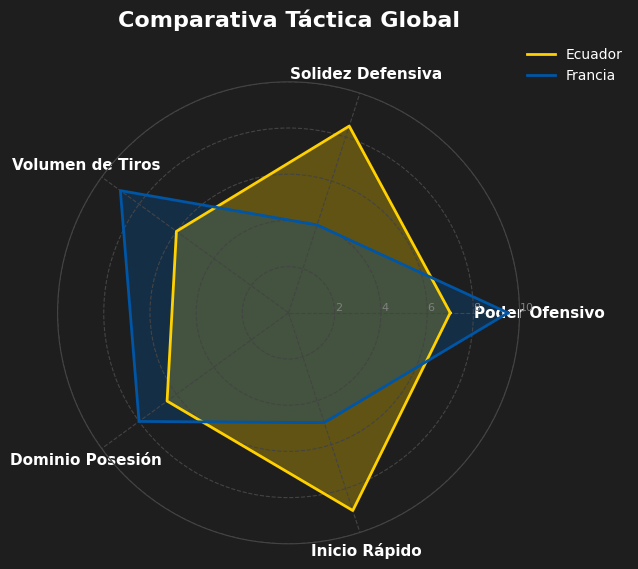

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Datos para el Radar
categorias = ['Poder Ofensivo', 'Solidez Defensiva', 'Volumen de Tiros', 'Dominio Posesión', 'Inicio Rápido']
N = len(categorias)

# Valores (escala 1 a 10 para normalizar las métricas)
valores_ecuador = [7.0, 8.5, 6.0, 6.5, 9.0]
valores_francia = [9.5, 4.0, 9.0, 8.0, 5.0]

# Cálculo de ángulos para el radar
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]
valores_ecuador += valores_ecuador[:1]
valores_francia += valores_francia[:1]

# Configuración visual (Fondo JodaAnalisis)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

# Ejes y etiquetas
plt.xticks(angulos[:-1], categorias, color='white', size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([2, 4, 6, 8, 10], ["2","4","6","8","10"], color="grey", size=8)
plt.ylim(0, 10)

# Colores de las líneas guía
ax.spines['polar'].set_color('#444444')
ax.grid(color='#444444', linestyle='--')

# Trazar Ecuador (Amarillo)
ax.plot(angulos, valores_ecuador, linewidth=2, linestyle='solid', color='#FFD100', label='Ecuador')
ax.fill(angulos, valores_ecuador, color='#FFD100', alpha=0.3)

# Trazar Francia (Azul)
ax.plot(angulos, valores_francia, linewidth=2, linestyle='solid', color='#0055A4', label='Francia')
ax.fill(angulos, valores_francia, color='#0055A4', alpha=0.3)

# Título y Leyenda
plt.title('Comparativa Táctica Global', size=16, color='white', y=1.1, fontweight='bold')
legend = plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
legend.get_frame().set_facecolor('#1e1e1e')
legend.get_frame().set_edgecolor('#1e1e1e')
for text in legend.get_texts():
    text.set_color("white")

# Guardar la imagen
plt.savefig('radar_tactico.png', dpi=300, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()